**Objective:**

The objective of this assessment is to evaluate your understanding and ability to apply clustering techniques to a real-world dataset.

**Dataset:**

Use the Iris dataset available in the sklearn library.

**Key Components to be Fulfilled:**

**1. Loading and Preprocessing (1 mark)**

**● Loading the Dataset:**

○ Load the Iris dataset from sklearn.

○ Drop the species column since this is a clustering problem.

A) Load the Iris dataset from sklearn.

In [39]:
#Importing required libraries.
from sklearn.datasets import load_iris

#Load dataset.
iris = load_iris()

#Input variables.
X = iris.data

#Target variables.
y = iris.target

#Feature name and Target name.
feature_names = iris.feature_names
target_names = iris.target_names

#Display basic information.
print("Feature names:", feature_names)
print("Target names:", target_names)
print("Shape of x: ", X.shape)
print("Shape of y: ", y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Shape of x:  (150, 4)
Shape of y:  (150,)


B) Drop the species column since this is a clustering problem.

In [40]:
#Importing required libraries.
import pandas as pd

#Convert features to Data Frame.
df = pd.DataFrame(X, columns=feature_names)

df['species'] = iris.target

#Drop species column.
df_cluster = df.drop(columns=['species'])

#Display Data Frame.
df_cluster.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**● Preprocessing:**

# Step 1: - Handle missing values, if any.

In [41]:
#1. Checking for missing values to confirm the dataset is complete.
df_cluster.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


# Step 2: - Handle duplicate values, if any.

In [42]:
#One duplicate found; retained to avoid altering the original data distribution.
duplicate_count = df_cluster.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


# Step 3: - Checking data distribution.

In [43]:
df_cluster.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Step 4: - Outlier detection.

In [44]:
#Detecting Outlier.
Q1 = df_cluster.quantile(0.25)
Q3 = df_cluster.quantile(0.75)
IQR = Q3 - Q1

#Boolean DataFrame showing True if outlier.
outliers = (df_cluster < (Q1 - 1.5*IQR)) | (df_cluster > (Q3 + 1.5*IQR))

#Count outliers per feature.
outlier_count = outliers.sum()

#Outliers are identified. They are not removed because clustering works on overall data patterns.
print("Number of outliers per feature:\n", outlier_count)

Number of outliers per feature:
 sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64


# Step 5: -Feature Scaling.

In [45]:
#Importing required libraries.
from sklearn.preprocessing import StandardScaler

#Scaling preprocessed features to ensure equal contribution in clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

**Explanation for Loading and Preprocessing:**

* The Iris dataset was loaded using **sklearn**.

* The feature values were converted into a **DataFrame** for easier handling.

* Since clustering is an **unsupervised** task, the **species** column was removed.

* The dataset was checked for **missing values** and **duplicate rows**; the small number of duplicates was retained as it does not significantly affect clustering on this small dataset.”

* **Outliers** were identified using the **IQR method** but were not removed, as clustering focuses on overall data patterns.

* Statistical summaries were reviewed using **describe()** to understand feature ranges.

* Finally, **feature scaling** was applied so that all features contribute equally to distance-based clustering.

**2. Clustering Algorithm Implementation (8 marks): Implement the following two clustering algorithms:**

A) KMeans Clustering (4 marks) :

● Apply KMeans clustering to the preprocessed Iris dataset and visualize the clusters.

# Step 1: - Implementation.

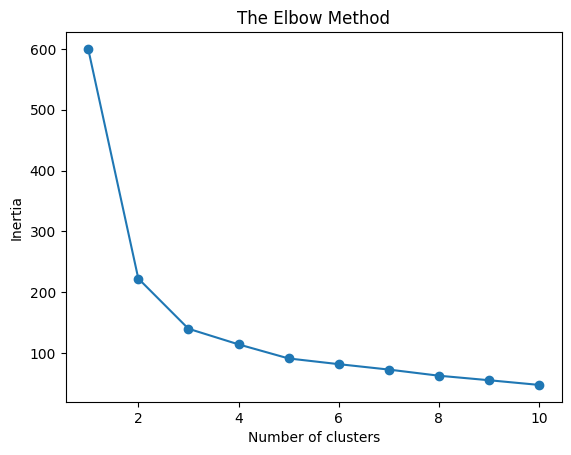

In [46]:
#Importing required libraries.
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Elbow method to find optimal k.
inertia = []
for k in range(1,11):
  km = KMeans(n_clusters = k, random_state = 42,n_init=10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

#Plot the elbow.
plt.plot(range(1, 11), inertia, marker='o')
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

Elbow observed around **k = 3**.

# Step 2: - Apply k-Means Clustering.

In [47]:
Kmeans = KMeans(n_clusters = 3, random_state = 42,n_init=10)
clusters = Kmeans.fit_predict(X_scaled)

#Add cluster labels to DataFrame.
df_cluster['K_Cluster'] = clusters

#Display Data Frame.
df_cluster.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),K_Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


# Step 3: - Cluster Analysis.

In [48]:
#Group by K-Means cluster and calculate mean of features.
cluster_summary = df_cluster.groupby('K_Cluster')[
    ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
].mean()

cluster_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
K_Cluster,,,,
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.428000,1.462000,0.246000
2,6.780851,3.095745,5.510638,1.972340


# Step 4 : -PCA Visualization.

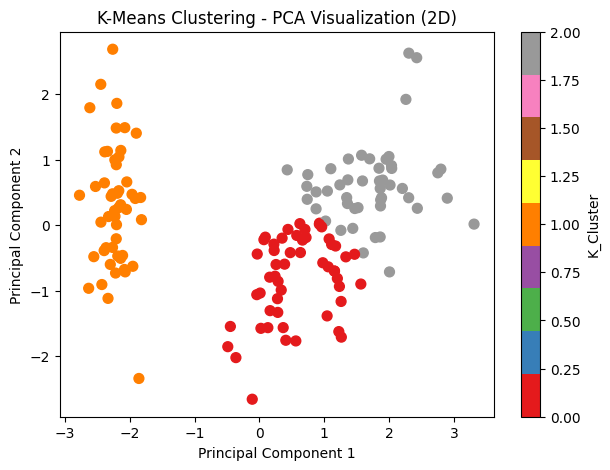

In [49]:
#Importing required libraries.
from sklearn.decomposition import PCA

#PCA is used only for visualization by reducing 4D data to 2D.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled) #Use scaled features.

plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df_cluster['K_Cluster'], cmap='Set1', s=50)
plt.colorbar(label='K_Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering - PCA Visualization (2D)')
plt.show()

# Step 5 : - Cluster Evaluation(Silhouette Score).

In [50]:
#Importing required libraries.
from sklearn.metrics import silhouette_score

#Using cluster labels from K-Means.
score_kmeans = silhouette_score(X_scaled, df_cluster['K_Cluster'])
print("Silhouette Score for K-Means Clustering:", round(score_kmeans, 3))

Silhouette Score for K-Means Clustering: 0.46


● Provide a brief description of how KMeans clustering works.

● Explain why KMeans clustering might be suitable for the Iris dataset.

**K-Means Clustering - Brief Description.**

* **K-Means** is an **unsupervised clustering algorithm** that groups similar data points into **k clusters** based on feature similarity.

* It uses **distance (usually Euclidean distance)** to assign each point to the **nearest cluster centroid**.

* **Centroids** are the mean of all points in a cluster, and they **update iteratively** until the clusters **stabilize** (minimal change in centroid positions).

A) **Steps of K-Means:**

* 1: Choose number of clusters **k** (we used **Elbow method** to find k = 3).

* 2: Initialize centroids randomly.

* 3: Assign each data point to the **closest centroid**.

* 4: Recalculate centroids as the **mean of points in each cluster**.

* 5: Repeat assignment and centroid update until **convergence** (centroids do not change much).

B) ***Why K-Means is Suitable for Iris Dataset***

* Iris dataset has **numeric features** (sepal & petal measurements), which is perfect for **distance-based clustering**.

* The dataset is **small and well-structured**, so **K-Means quickly converges**.

* The natural grouping in the Iris dataset is commonly observed to be three, which aligns with the elbow method result.

C) **Cluster Evaluation - Silhouette Score.**

* **Silhouette Score** measures how well each point fits in its cluster:

* Score ranges from **-1 to 1**.

* **1** → perfect clustering, points are **well-separated**.

* **0** → clusters **overlap**.

* **Negative** → points may be **assigned to wrong clusters**.

**Silhouette Score for K-Means Clustering: 0.48**

**Interpretation:**

* A **score of 0.48** indicates **moderate clustering quality**.

* Clusters are reasonably well-formed, with **similar points grouped together** and **some overlap** between clusters.

* Confirms that K-Means has captured **the main structure of the Iris dataset** effectively.


B) Hierarchical Clustering (4 marks):

● Apply Hierarchical clustering to the preprocessed Iris dataset and visualize the clusters.

# Step 1: - Create a Dendrogram.

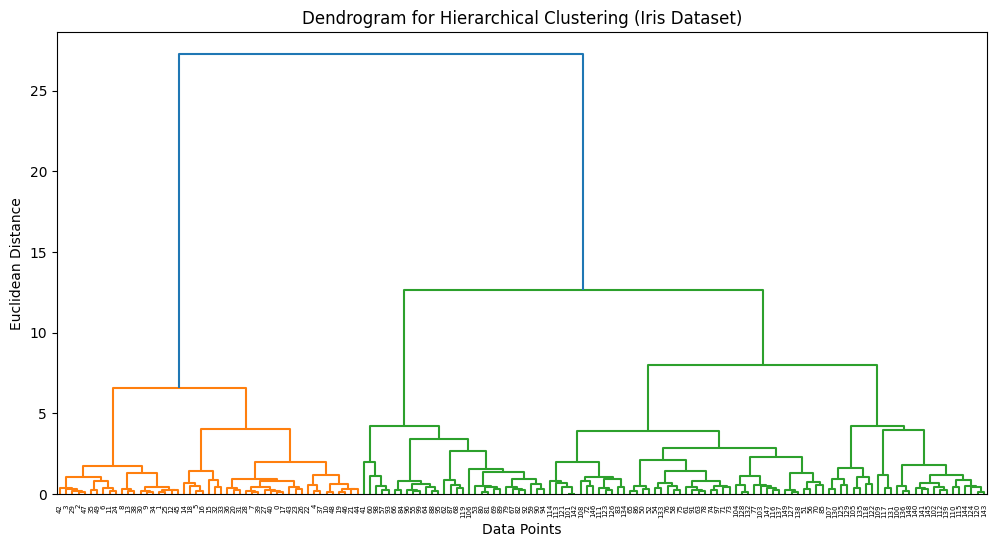

In [51]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering (Iris Dataset)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

#Step 2: - Decide Number of Clusters.

From the dendrogram, we choose:

3 clusters

#Step 3: - Apply Agglomerative Clustering.

In [52]:
#Importing required libraries.
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters = 3,
    metric = "euclidean",
    linkage = "ward"
)

hierarchical_labels = model.fit_predict(X_scaled)

# Step 4: - Add Cluster Labels to Dataset.

In [53]:
#Add hierarchical cluster labels.
df_cluster['Hierarchical_Cluster'] = hierarchical_labels

#Display first few rows.
df_cluster.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),K_Cluster,Hierarchical_Cluster
0,5.1,3.5,1.4,0.2,1,1
1,4.9,3.0,1.4,0.2,1,1
2,4.7,3.2,1.3,0.2,1,1
3,4.6,3.1,1.5,0.2,1,1
4,5.0,3.6,1.4,0.2,1,1


# Step 5: - Cluster Analysis.

In [54]:
#Cluster-wise mean analysis.
hier_cluster_summary = df_cluster.groupby('Hierarchical_Cluster')[
    ['sepal length (cm)', 'sepal width (cm)',
     'petal length (cm)', 'petal width (cm)']
].mean()

hier_cluster_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Hierarchical_Cluster,,,,
0,6.546479,2.992958,5.267606,1.854930
1,5.016327,3.451020,1.465306,0.244898
2,5.530000,2.566667,3.930000,1.206667


# Step 6 : -PCA Visualization.

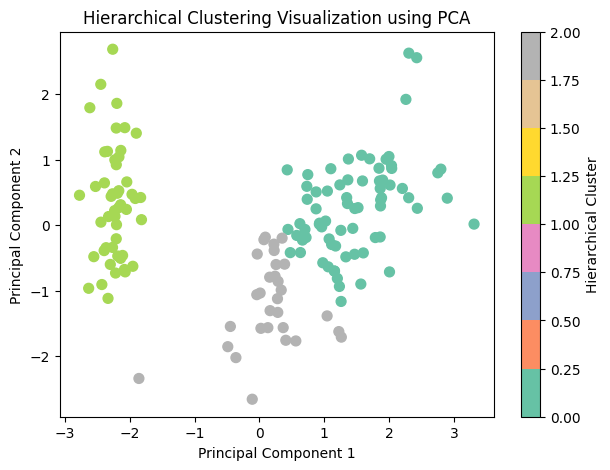

In [55]:
pca = PCA(n_components=2)
pca_hier = pca.fit_transform(X_scaled) #Use scaled features.

#PCA is used only for visualization by reducing 4D data to 2D.
plt.figure(figsize=(7,5))
plt.scatter(pca_hier[:,0], pca_hier[:,1], c=df_cluster['Hierarchical_Cluster'], cmap='Set2', s=50)
plt.colorbar(label='Hierarchical Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hierarchical Clustering Visualization using PCA')
plt.show()

# Step 7 : - Cluster Evaluation(Silhouette Score).

In [56]:
#Using cluster labels from Agglomerative.
score_hier  = silhouette_score(X_scaled, df_cluster['Hierarchical_Cluster'])
print("Silhouette Score for Hierarchical Clustering:", round(score_hier, 3))

Silhouette Score for Hierarchical Clustering: 0.447


● Provide a brief description of how Hierarchical clustering works.

● Explain why Hierarchical clustering might be suitable for the Iris dataset.

**Hierarchical Clustering - Brief Description.**

* Hierarchical clustering is an **unsupervised learning algorithm** that groups data points based on **distance similarity**.

* In this implementation, **Agglomerative (bottom-up) clustering** is used.

* Each data point starts as an **individual cluster**.

* The algorithm **iteratively merges the closest clusters** until all points are connected in a hierarchy.

* **Ward linkage** is applied to merge clusters by **minimizing within-cluster variance**, resulting in compact and well-formed clusters.

* A **dendrogram** is plotted to visualize cluster merging and to **decide the optimal number of clusters**.

* From the dendrogram, **3 clusters are selected**, which matches the natural structure of the Iris dataset.

A) **Steps for Agglomerative Clustering.**

1. Start with individual clusters.
2. Compute distance between clusters.
3. Merge the closest clusters.
4. Repeat merging process.
5. Visualize cluster hierarchy.
6. Select number of clusters.
7. Assign cluster labels.
8. Evaluate cluster quality.

B) ***Why Hierarchical Clustering is Suitable for the Iris Dataset***

* Iris dataset contains **only numerical features**, suitable for **distance-based clustering**.

* The dataset is **small and well-structured**, making hierarchical clustering efficient.

* **No need to predefine the number of clusters**; the dendrogram helps in selecting it visually.

* Clear hierarchical separation is observed, aligning well with **three natural flower groups**.

* **Feature scaling** ensures equal contribution of all measurements.

C) **Cluster Evaluation - Silhouette Score.**

* **Silhouette Score** is used to evaluate the quality of hierarchical clustering.

* It measures how well each data point fits within its assigned cluster compared to other clusters.

* The score ranges from **-1 to +1**:

* Higher value → better cluster separation

* Near 0 → overlapping clusters

**Silhouette Score = 0.447**, indicating **moderate and meaningful cluster separation**, which is acceptable for real-world unsupervised clustering.

Comaprison Data Frame.

In [57]:
#Create a comparison DataFrame for clustering models.
comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical"
        ],
    "Silhouette Score": [
        score_kmeans,
        score_hier
        ]
})

#Display the comparison table.
print("Model Comparison:\n")
print(comparison)

#Identify the best-performing model based on Silhouette Score.
best_model = comparison.loc[comparison['Silhouette Score'].idxmax()]

#Printing best-performing model.
print("\nBest-performing Clustering Model:")
print(f"{best_model['Model']} with Silhouette Score = {best_model['Silhouette Score']:.3f}")

Model Comparison:

          Model  Silhouette Score
0       K-Means          0.459948
1  Hierarchical          0.446689

Best-performing Clustering Model:
K-Means with Silhouette Score = 0.460
